In [36]:
import torch
from torch import nn
from torch import optim
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import seaborn as sns
from time import sleep
device = "cuda" if torch.cuda.is_available() else "cpu"

In [37]:
device

'cuda'

In [38]:
transform = transforms.Compose([transforms.ToTensor()])

In [39]:
train = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test = MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

In [40]:
type(train), type(test)

(torchvision.datasets.mnist.MNIST, torchvision.datasets.mnist.MNIST)

In [41]:
train_loader = DataLoader(
    train,
    batch_size=64,
    shuffle=True,
    num_workers=6
)
test_loader = DataLoader(
    test,
    batch_size=64,
    shuffle=False,
    num_workers=2
)
print(f"number of training batches: {len(train_loader)}, number of testing batches: {len(test_loader)}")

number of training batches: 938, number of testing batches: 157


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64])


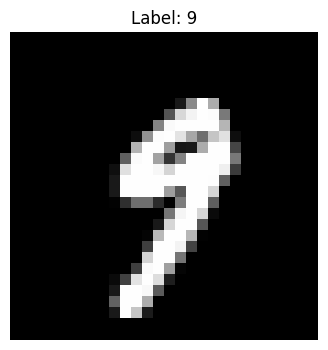

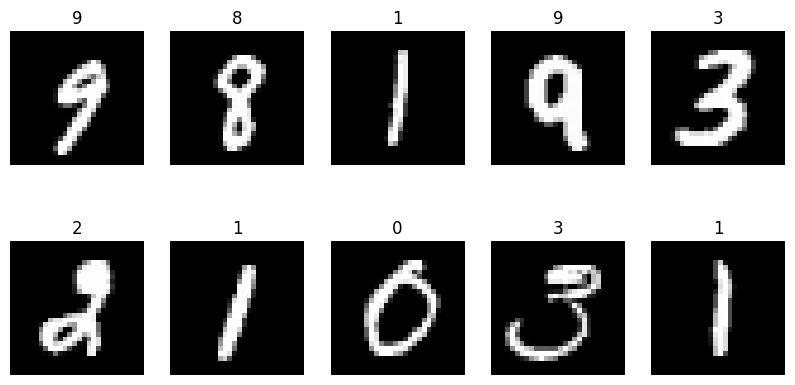

In [42]:
# Grab one batch of data
# 'X' will be the images, 'y' will be the labels (the actual digits)
X_batch, y_batch = next(iter(train_loader))

# X_batch shape: [batch_size, channels, height, width]
print(f"Shape of X [N, C, H, W]: {X_batch.shape}")
print(f"Shape of y: {y_batch.shape}")

# Plot a single image from the batch
plt.figure(figsize=(4, 4))
image = X_batch[0].squeeze() # Remove the channel dimension (1x28x28 -> 28x28)
label = y_batch[0]

# Denormalize the image for correct plotting (reverses the Normalize transform)
# New_value = Old_value * std + mean
mean = 0.1307
std = 0.3081
image_denorm = image * std + mean

plt.imshow(image_denorm, cmap="gray")
plt.title(f"Label: {label.item()}") # .item() extracts the number from the tensor
plt.axis("off")
plt.show()

# Display a grid of images
plt.figure(figsize=(10, 5))
for i in range(10): # Display the first 10 images
    ax = plt.subplot(2, 5, i + 1) # Create a 2 row, 5 column grid
    image = X_batch[i].squeeze()
    image_denorm = image * std + mean # Denormalize
    plt.imshow(image_denorm, cmap="gray")
    plt.title(f"{y_batch[i].item()}")
    plt.axis("off")
plt.show()

In [43]:
import torch.nn.functional as F # We need F.relu and F.max_pool2d in the forward pass

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        # Always call the parent class's constructor
        super(SimpleCNN, self).__init__()

        # --- Feature Extraction Section ---

        # 1st Convolutional Layer:
        # nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        # Input: [1, 28, 28] (1 channel for grayscale, 28x28 image)
        # Output: [10, 24, 24] (10 feature maps, size reduces by 4 pixels due to 5x5 kernel)
        self.conv1 = nn.Conv2d(
            in_channels=1,     # Input is a single grayscale channel
            out_channels=10,   # We want 10 different filters (features)
            kernel_size=5,     # A 5x5 filter
        )

        # 2nd Convolutional Layer:
        # Input: [10, 12, 12] (after a pooling layer, as shown below)
        # Output: [20, 8, 8] (20 feature maps, size reduces by 4 pixels due to 5x5 kernel)
        self.conv2 = nn.Conv2d(
            in_channels=10,    # Input is the 10 feature maps from conv1's output
            out_channels=20,   # We want 20 different, more complex features
            kernel_size=5,
        )

        # Max Pooling Layer:
        # nn.MaxPool2d(kernel_size, stride)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Classification Section (Fully Connected Layers) ---

        # We need to figure out the size of the tensor after all the Conv/Pool layers.
        # After conv2 and a final pool, the size is 20 feature maps x 4x4 spatial size.
        # 20 * 4 * 4 = 320
        self.fc1 = nn.Linear(
            in_features=20 * 4 * 4, # 320 total features after flattening
            out_features=50,       # Arbitrary choice for a hidden layer size
        )

        # Output Layer:
        # Maps the 50 hidden features to 10 output classes (digits 0-9)
        self.fc2 = nn.Linear(
            in_features=50,
            out_features=num_classes # 10 classes (0 through 9)
        )

    # The forward() method defines the actual flow of data through the network
    def forward(self, x):
        # 1. First Conv -> ReLU -> Pool
        # x shape: [batch_size, 1, 28, 28]
        x = self.pool(F.relu(self.conv1(x)))
        # After conv1: [batch_size, 10, 24, 24]
        # After pool:  [batch_size, 10, 12, 12] (24/2 = 12)

        # 2. Second Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # After conv2: [batch_size, 20, 8, 8]
        # After pool:  [batch_size, 20, 4, 4] (8/2 = 4)

        # 3. Flatten the tensor for the Fully Connected layers
        # x.shape: [batch_size, 20, 4, 4] -> Flattened to [batch_size, 320]
        x = torch.flatten(x, 1) # '1' means flatten all dimensions EXCEPT the batch dimension (0)

        # 4. First Fully Connected -> ReLU
        x = F.relu(self.fc1(x))
        # x shape: [batch_size, 50]

        # 5. Output Layer (Logits for 10 classes)
        x = self.fc2(x)
        # x shape: [batch_size, 10]

        return x

# Instantiate the model and move it to the GPU (your RTX 5070!)
model = SimpleCNN(num_classes=10).to(device)

# Print the model structure
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001)

In [45]:
def training_epoch(dataloader, model, criterion, device, optimizer):
    model.train()
    tloss = 0.0
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        lgt = model(X)
        loss = criterion(lgt, y)
        tloss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 == 0:
            current = batch * len(X)
            print(f"Loss: {loss.item():.4f}  [{current:>5d}/{size:>5d}]")
    avg_loss = tloss / len(dataloader)
    print(f"\nTraining Loss for Epoch: {avg_loss:.4f}")
    return avg_loss

In [46]:
def test_epoch(dataloader, model, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    size = len(dataloader.dataset)
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            lgt = model(X)
            test_loss += criterion(lgt, y).item()
            predicted_class = lgt.argmax(dim=1)
            correct += (predicted_class == y).type(torch.float).sum().item()
    avg_test_loss = test_loss / len(dataloader)
    accuracy = correct / size
    print(f"Test Error: \n Accuracy: {(100*accuracy):.1f}%, Avg loss: {avg_test_loss:.4f} \n")
    return accuracy, avg_test_loss

In [47]:
EPOCHS = 25
print(f"TRAINING TIME!!!\n training for epochs: {EPOCHS}\n -----------------------\n training on {device} \n------------")
for i in range(5):
    print(f"TRAINING IN {i}/5 SECS")
    sleep(1)
for t in range(EPOCHS):
    print(f"Epoch {t+1}\n-------------------------------")
    training_epoch(train_loader, model, criterion, device, optimizer)
    test_epoch(test_loader, model, criterion, device)
print("TRAINING WAS SUCESSSSSSSSSSSSSS")

TRAINING TIME!!!
 training for epochs: 25
 -----------------------
 training on cuda 
------------
TRAINING IN 0/5 SECS
TRAINING IN 1/5 SECS
TRAINING IN 2/5 SECS
TRAINING IN 3/5 SECS
TRAINING IN 4/5 SECS
Epoch 1
-------------------------------
Loss: 2.3057  [    0/60000]
Loss: 0.3647  [ 6400/60000]
Loss: 0.3745  [12800/60000]
Loss: 0.1550  [19200/60000]
Loss: 0.2491  [25600/60000]
Loss: 0.1541  [32000/60000]
Loss: 0.0957  [38400/60000]
Loss: 0.1407  [44800/60000]
Loss: 0.1651  [51200/60000]
Loss: 0.1859  [57600/60000]

Training Loss for Epoch: 0.2897
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.0897 

Epoch 2
-------------------------------
Loss: 0.1234  [    0/60000]
Loss: 0.1598  [ 6400/60000]
Loss: 0.0578  [12800/60000]
Loss: 0.0420  [19200/60000]
Loss: 0.0949  [25600/60000]
Loss: 0.0760  [32000/60000]
Loss: 0.1816  [38400/60000]
Loss: 0.0335  [44800/60000]
Loss: 0.0849  [51200/60000]
Loss: 0.0404  [57600/60000]

Training Loss for Epoch: 0.0833
Test Error: 
 Accuracy: 98.1%, Avg loss:

KeyboardInterrupt: 

In [ ]:
# Grab the first 5 samples from the raw test dataset
test_samples = []
for i in range(5):
    # Get the raw tensor and true label from the dataset
    image_tensor, true_label = test[i]
    
    # Get the model's prediction
    predicted_label = predict_single_image(model, image_tensor, device)
    
    # Denormalize the image for display (if you used simple transform, 
    # it's already 0-1 and this is fine)
    image_display = image_tensor.squeeze()
    
    test_samples.append({
        'image': image_display, 
        'true': true_label, 
        'predicted': predicted_label
    })

# Plotting the results
plt.figure(figsize=(12, 4))
for i, sample in enumerate(test_samples):
    ax = plt.subplot(1, 5, i + 1)
    
    plt.imshow(sample['image'], cmap="gray")
    
    color = 'green' if sample['predicted'] == sample['true'] else 'red'
    title = f"True: {sample['true']}\nPred: {sample['predicted']}"
    
    plt.title(title, color=color)
    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Unseen Test Data (Green = Correct, Red = Wrong)", 
    y=1.05, 
    fontsize=14
)
plt.show()

NameError: name 'predict_single_image' is not defined

In [ ]:
torch.save(model, "MNISTCnn.pth")

In [ ]:
import torch.nn.functional as F # We need F.relu and F.max_pool2d in the forward pass

class testCNN(nn.Module):
    def __init__(self, num_classes=10):
        # Always call the parent class's constructor
        super().__init__()

        # --- Feature Extraction Section ---

        # 1st Convolutional Layer:
        # nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        # Input: [1, 28, 28] (1 channel for grayscale, 28x28 image)
        # Output: [10, 24, 24] (10 feature maps, size reduces by 4 pixels due to 5x5 kernel)
        self.conv1 = nn.Conv2d(
            in_channels=1,     # Input is a single grayscale channel
            out_channels=10,   # We want 10 different filters (features)
            kernel_size=5,     # A 5x5 filter
        )

        # 2nd Convolutional Layer:
        # Input: [10, 12, 12] (after a pooling layer, as shown below)
        # Output: [20, 8, 8] (20 feature maps, size reduces by 4 pixels due to 5x5 kernel)
        self.conv2 = nn.Conv2d(
            in_channels=10,    # Input is the 10 feature maps from conv1's output
            out_channels=20,   # We want 20 different, more complex features
            kernel_size=5,
        )

        # Max Pooling Layer:
        # nn.MaxPool2d(kernel_size, stride)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Classification Section (Fully Connected Layers) ---

        # We need to figure out the size of the tensor after all the Conv/Pool layers.
        # After conv2 and a final pool, the size is 20 feature maps x 4x4 spatial size.
        # 20 * 4 * 4 = 320
        self.fc1 = nn.Linear(
            in_features=20 * 4 * 4, # 320 total features after flattening
            out_features=50,       # Arbitrary choice for a hidden layer size
        )

        # Output Layer:
        # Maps the 50 hidden features to 10 output classes (digits 0-9)
        self.fc2 = nn.Linear(
            in_features=50,
            out_features=num_classes # 10 classes (0 through 9)
        )

    # The forward() method defines the actual flow of data through the network
    def forward(self, x):
        # 1. First Conv -> ReLU -> Pool
        # x shape: [batch_size, 1, 28, 28]
        x = self.pool(F.relu(self.conv1(x)))
        # After conv1: [batch_size, 10, 24, 24]
        # After pool:  [batch_size, 10, 12, 12] (24/2 = 12)

        # 2. Second Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # After conv2: [batch_size, 20, 8, 8]
        # After pool:  [batch_size, 20, 4, 4] (8/2 = 4)


        return x

# Instantiate the model and move it to the GPU (your RTX 5070!)
model1 = testCNN(num_classes=10).to(device)

# Print the model structure
print(model1)

testCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [ ]:
x, y = next(iter(test_loader))
img, img1=x[0], x[0]
img.shape
img = img.to(device)

In [ ]:
img1 = model1(img)

In [ ]:
img.shape

torch.Size([1, 28, 28])

In [ ]:
img1.shape

torch.Size([20, 4, 4])